# 07b debug — diagnostic torus 3D plat

Objectif : comprendre pourquoi mes ellipses sont aplaties dans le plan de l'anneau,
alors que chez Antoine elles forment un vrai torus.

**Hypothèses testées** :
1. Le ratio std_n / std_b est trop déséquilibré (trajectoire trop planaire)
2. La trajectoire de référence Fourier est elle-même dégénérée
3. Le paramètre τ = 16 produit un attracteur trop plat ; un τ plus petit donnerait du volume 3D

In [2]:
from resilience import paths, participants, config
from resilience.io import writer
from resilience.processing import detection, tde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from scipy.ndimage import gaussian_filter1d
%matplotlib inline

In [3]:
# Ré-importer les fonctions du 07b (copier-coller)

def _fit_plane_poly11(x, y, z):
    A = np.column_stack([np.ones_like(x), x, y])
    coeffs, *_ = np.linalg.lstsq(A, z, rcond=None)
    return coeffs

def _rotation_to_align(a, b):
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    c = np.cross(a, b)
    angle = np.arccos(np.clip(np.dot(a, b), -1, 1))
    axis = c / (np.linalg.norm(c) + 1e-12)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K

def _fourier_design_matrix(phases_deg, order):
    phi = np.deg2rad(phases_deg).reshape(-1, 1)
    k = np.arange(1, order + 1).reshape(1, -1)
    return np.hstack([np.ones((len(phases_deg), 1)),
                      np.sin(phi * k), np.cos(phi * k)])

def fourier_reference_trajectory(XR_3d, fourier_order=8):
    X, Y, Z = XR_3d[:, 0], XR_3d[:, 1], XR_3d[:, 2]
    Xo, Yo, Zo = np.nanmean(X), np.nanmean(Y), np.nanmean(Z)
    coeffs = _fit_plane_poly11(X, Y, Z)
    normal_vec = np.array([-coeffs[1], -coeffs[2], 1.0])
    R = _rotation_to_align(np.array([0., 0., 1.]), normal_vec)
    proj = np.column_stack([X - Xo, Y - Yo, Z - Zo]) @ R
    phase_pre = np.degrees(np.arctan2(proj[:, 1], proj[:, 0])) + 180
    idx_sorted = np.argsort(np.round(phase_pre))
    phase_sorted = np.round(phase_pre)[idx_sorted].astype(int) % 360
    Xs, Ys, Zs = X[idx_sorted], Y[idx_sorted], Z[idx_sorted]
    phase_fit = np.concatenate([phase_sorted, phase_sorted + 360]).astype(float)
    x_fit = np.concatenate([Xs, Xs])
    y_fit = np.concatenate([Ys, Ys])
    z_fit = np.concatenate([Zs, Zs])
    valid = np.isfinite(phase_fit) & np.isfinite(x_fit) & np.isfinite(y_fit) & np.isfinite(z_fit)
    phase_fit, x_fit, y_fit, z_fit = phase_fit[valid], x_fit[valid], y_fit[valid], z_fit[valid]
    phase_ref = np.arange(360)
    A_fit = _fourier_design_matrix(phase_fit, fourier_order)
    A_ref = _fourier_design_matrix(phase_ref, fourier_order)
    bx, *_ = np.linalg.lstsq(A_fit, x_fit, rcond=None)
    by, *_ = np.linalg.lstsq(A_fit, y_fit, rcond=None)
    bz, *_ = np.linalg.lstsq(A_fit, z_fit, rcond=None)
    ref_traj = np.column_stack([A_ref @ bx, A_ref @ by, A_ref @ bz])
    phase_data = np.column_stack([Xs, Ys, Zs, phase_sorted])
    return ref_traj, phase_data

def compute_local_frames(ref_traj):
    n = len(ref_traj)
    T, N, B = np.zeros((n, 3)), np.zeros((n, 3)), np.zeros((n, 3))
    def _norm(v):
        nrm = np.linalg.norm(v)
        return v / nrm if nrm > 1e-12 else v
    T[0] = _norm(ref_traj[1] - ref_traj[0])
    T[-1] = _norm(ref_traj[-1] - ref_traj[-2])
    for i in range(1, n - 1):
        T[i] = _norm(ref_traj[i + 1] - ref_traj[i - 1])
    N[0] = _norm(T[1] - T[0])
    N[-1] = _norm(T[-1] - T[-2])
    for i in range(1, n - 1):
        N[i] = _norm(T[i + 1] - T[i - 1])
    for i in range(n):
        B[i] = _norm(np.cross(T[i], N[i]))
    return T, N, B

def compute_local_std(ref_traj, phase_data):
    n = len(ref_traj)
    T, N, B = compute_local_frames(ref_traj)
    std_n = np.full(n, np.nan)
    std_b = np.full(n, np.nan)
    for k in range(n):
        mask = phase_data[:, 3] == k
        if mask.sum() < 2:
            continue
        vecs = phase_data[mask, :3] - ref_traj[k]
        std_n[k] = np.nanstd(vecs @ N[k], ddof=1)
        std_b[k] = np.nanstd(vecs @ B[k], ddof=1)
    return std_n, std_b, N, B, T

## Diagnostic 1 : caractériser l'attracteur sur P012/silence

On regarde l'épaisseur 3D via les eigenvalues de la covariance.

In [4]:
EXAMPLE_P = '012WaCh'
EXAMPLE_COND = 'silence'

# Charger signal
d = writer.load_processed(EXAMPLE_P, EXAMPLE_COND)
sig = d['signal_final'].astype(float)
t = d['time_final'].astype(float)

# Pert detection
dos_xy = np.stack([d[f'raw_Dos{j:02d}'][:, :2] for j in range(1, 5)], axis=0)
sac_xy = np.nanmean(dos_xy, axis=0)
for ax_idx in range(2):
    col = sac_xy[:, ax_idx]
    if np.isnan(col).any():
        idx = np.arange(len(col))
        valid = ~np.isnan(col)
        if valid.sum() >= 2:
            col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
        sac_xy[:, ax_idx] = col
det = detection.detect_sand_by_bbox(sac_xy)
pert_entry, pert_exit = det['entry_t'], det['exit_t']

# Charger params TDE
df_tde = pd.read_csv(paths.OUTPUTS_DIR / 'tables' / '04_tde_per_participant.csv')
tau_p = int(df_tde[df_tde['participant'] == EXAMPLE_P]['tau_p'].iloc[0])
m_p   = int(df_tde[df_tde['participant'] == EXAMPLE_P]['m_p'].iloc[0])
print(f"τ_p = {tau_p}, m_p = {m_p}")

# Test différentes valeurs de tau pour voir l'effet sur l'épaisseur 3D
print("\nDiagnostic épaisseur 3D de l'attracteur (eigenvalues PCA des 3 dims) :\n")
print(f"{'tau':>5s} | {'λ1':>8s} | {'λ2':>8s} | {'λ3':>8s} | {'ratio λ3/λ1':>12s} | std_n moy | std_b moy")
print('-' * 90)

for tau_test in [5, 8, 10, 12, 14, 16, 20, 25]:
    XR = tde.phase_space_reconstruction(sig, tau=tau_test, dim=m_p)[:, :3]
    pad = (m_p - 1) * tau_test
    t_xr = t[pad:pad + XR.shape[0]]
    pert_mask = (t_xr >= pert_entry) & (t_xr <= pert_exit)
    XR_baseline = XR[~pert_mask]

    # PCA pour mesurer l'épaisseur
    cov = np.cov(XR_baseline.T)
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]  # décroissant
    ratio = eigvals[2] / eigvals[0]

    # std_n et std_b moyens
    ref_traj, phase_data = fourier_reference_trajectory(XR_baseline, fourier_order=8)
    std_n, std_b, N, B, T = compute_local_std(ref_traj, phase_data)

    print(f"{tau_test:>5d} | {eigvals[0]:>8.1f} | {eigvals[1]:>8.1f} | {eigvals[2]:>8.1f} | {ratio:>12.4f} | {np.nanmean(std_n):>9.2f} | {np.nanmean(std_b):>9.2f}")

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_9232\3254025344.py:11: RuntimeWarning: Mean of empty slice
  sac_xy = np.nanmean(dos_xy, axis=0)


τ_p = 16, m_p = 4

Diagnostic épaisseur 3D de l'attracteur (eigenvalues PCA des 3 dims) :

  tau |       λ1 |       λ2 |       λ3 |  ratio λ3/λ1 | std_n moy | std_b moy
------------------------------------------------------------------------------------------
    5 |    302.9 |     63.4 |      0.7 |       0.0023 |      3.99 |      1.09
    8 |    229.9 |    132.8 |      4.2 |       0.0182 |      5.56 |      2.00
   10 |    183.8 |    173.5 |      9.6 |       0.0522 |      5.95 |      2.93
   12 |    201.2 |    147.3 |     18.4 |       0.0912 |      5.99 |      3.92
   14 |    211.4 |    125.6 |     29.7 |       0.1405 |      5.67 |      5.01
   16 |    203.0 |    124.9 |     38.9 |       0.1914 |      5.29 |      5.75
   20 |    185.8 |    141.2 |     39.8 |       0.2140 |      5.20 |      6.11
   25 |    281.5 |     49.8 |     35.4 |       0.1258 |      6.58 |      5.99


## Diagnostic 2 : visualiser N et B à quelques points

Pour τ=16 (notre valeur), on trace la trajectoire de référence et les vecteurs N et B à quelques points (toutes les 30°) pour voir leur orientation.

std_n : min=2.78, mean=5.29, max=10.23
std_b : min=2.73, mean=5.75, max=9.73
ratio std_b / std_n moyen = 1.086


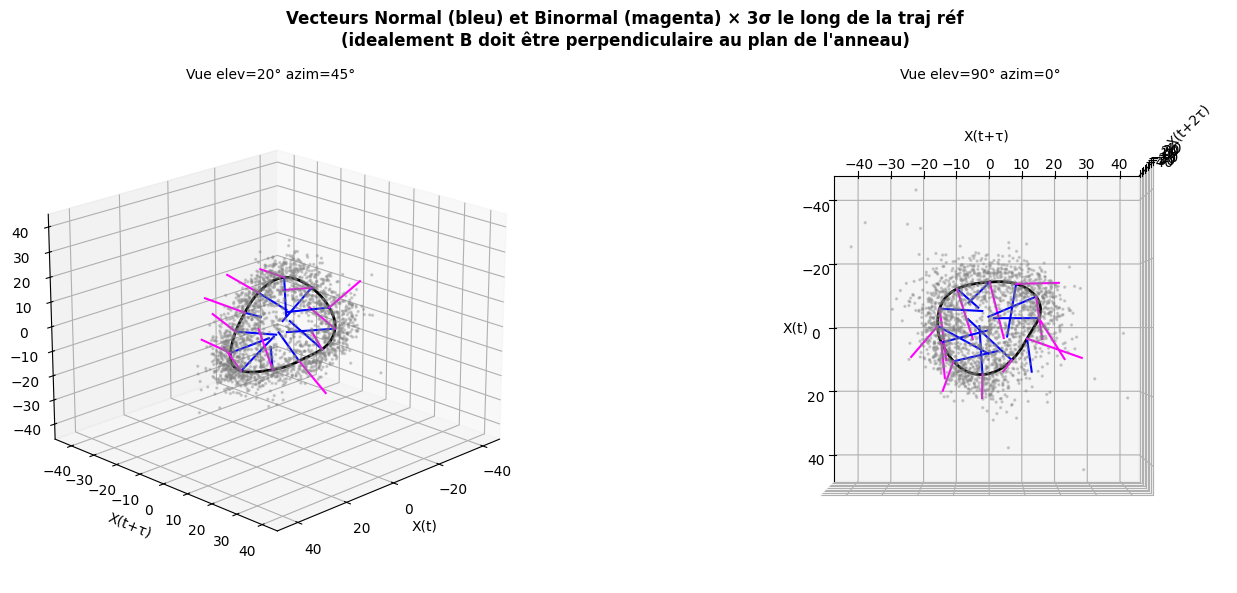

In [5]:
XR = tde.phase_space_reconstruction(sig, tau=tau_p, dim=m_p)[:, :3]
pad = (m_p - 1) * tau_p
t_xr = t[pad:pad + XR.shape[0]]
pert_mask = (t_xr >= pert_entry) & (t_xr <= pert_exit)
XR_baseline = XR[~pert_mask]

ref_traj, phase_data = fourier_reference_trajectory(XR_baseline, fourier_order=8)
std_n, std_b, N, B, T = compute_local_std(ref_traj, phase_data)

# Smoothing
std_n_smooth = gaussian_filter1d(np.nan_to_num(std_n, nan=np.nanmean(std_n)), sigma=5)
std_b_smooth = gaussian_filter1d(np.nan_to_num(std_b, nan=np.nanmean(std_b)), sigma=5)

print(f"std_n : min={np.nanmin(std_n):.2f}, mean={np.nanmean(std_n):.2f}, max={np.nanmax(std_n):.2f}")
print(f"std_b : min={np.nanmin(std_b):.2f}, mean={np.nanmean(std_b):.2f}, max={np.nanmax(std_b):.2f}")
print(f"ratio std_b / std_n moyen = {np.nanmean(std_b) / np.nanmean(std_n):.3f}")

# Plot : trajectoire ref + vecteurs N et B amplifiés à quelques points
fig = plt.figure(figsize=(15, 6))

for ax_idx, view_angle in enumerate([(20, 45), (90, 0)]):
    ax = fig.add_subplot(1, 2, ax_idx+1, projection='3d')
    ax.plot(ref_traj[:, 0], ref_traj[:, 1], ref_traj[:, 2],
            color='black', linewidth=2, label='Réf Fourier')
    ax.scatter(XR_baseline[::20, 0], XR_baseline[::20, 1], XR_baseline[::20, 2],
                color='gray', s=2, alpha=0.3)
    # Vecteurs N et B à plusieurs points, amplifiés par std_n / std_b
    step = 30
    for k in range(0, 360, step):
        p = ref_traj[k]
        # N en bleu (radial)
        n_end = p + N[k] * std_n_smooth[k] * 3
        ax.plot([p[0], n_end[0]], [p[1], n_end[1]], [p[2], n_end[2]],
                color='blue', linewidth=1.5)
        # B en magenta (binormal, perpendiculaire au plan)
        b_end = p + B[k] * std_b_smooth[k] * 3
        ax.plot([p[0], b_end[0]], [p[1], b_end[1]], [p[2], b_end[2]],
                color='magenta', linewidth=1.5)
    ax.view_init(elev=view_angle[0], azim=view_angle[1])
    ax.set_title(f'Vue elev={view_angle[0]}° azim={view_angle[1]}°', fontsize=10)
    ax.set_xlabel('X(t)'); ax.set_ylabel('X(t+τ)'); ax.set_zlabel('X(t+2τ)')

plt.suptitle(f'Vecteurs Normal (bleu) et Binormal (magenta) × 3σ le long de la traj réf\n'
              f'(idealement B doit être perpendiculaire au plan de l\'anneau)',
              fontweight='bold')
plt.tight_layout()
plt.show()

## Diagnostic 3 : tracer le torus dans 3 vues différentes

Si le torus est correct mais juste mal vu, on devrait le voir clairement sous un angle adéquat.

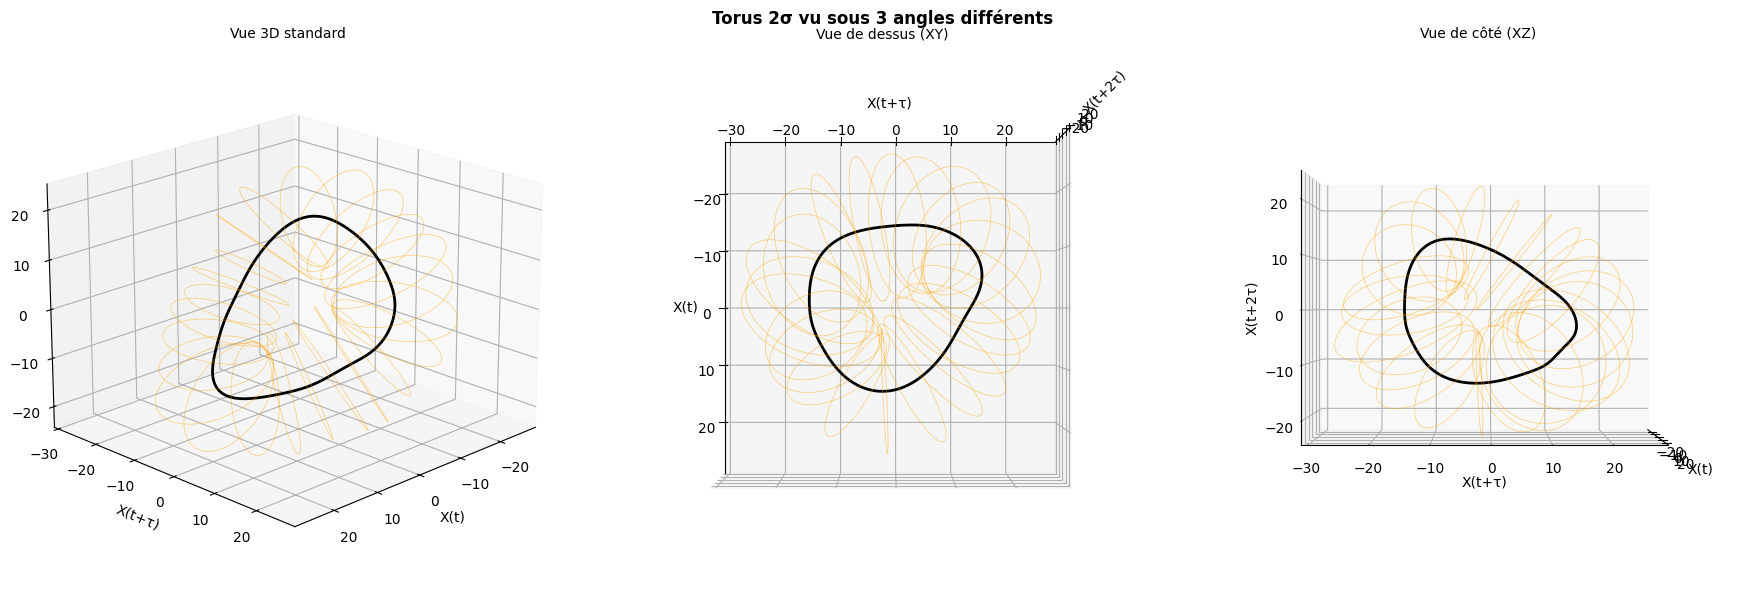

In [6]:
def generate_ellipses(ref_traj, std_n, std_b, N, B, scale=1.0, n_pts=50):
    theta = np.linspace(0, 2 * np.pi, n_pts)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    ellipses = np.zeros((len(ref_traj), n_pts, 3))
    for i in range(len(ref_traj)):
        a, b = scale * std_n[i], scale * std_b[i]
        if np.isnan(a) or np.isnan(b):
            ellipses[i] = np.nan
            continue
        e = np.outer(a * cos_t, N[i]) + np.outer(b * sin_t, B[i])
        ellipses[i] = e + ref_traj[i]
    return ellipses

# Générer ellipses 2σ
ellipses_2sigma = generate_ellipses(ref_traj, std_n_smooth, std_b_smooth, N, B, scale=2.0, n_pts=40)

# Tracer dans 3 vues différentes
fig = plt.figure(figsize=(18, 6))
views = [(20, 45), (90, 0), (0, 0)]
view_names = ['Vue 3D standard', 'Vue de dessus (XY)', 'Vue de côté (XZ)']

for i, ((elev, azim), name) in enumerate(zip(views, view_names)):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    # Traj ref noire
    ax.plot(ref_traj[:, 0], ref_traj[:, 1], ref_traj[:, 2],
            color='black', linewidth=2, label='Réf Fourier')
    # Ellipses 2σ
    for k in range(0, 360, 15):
        if not np.isnan(ellipses_2sigma[k]).any():
            ax.plot(ellipses_2sigma[k, :, 0], ellipses_2sigma[k, :, 1], ellipses_2sigma[k, :, 2],
                    color='orange', alpha=0.5, linewidth=0.5)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('X(t)'); ax.set_ylabel('X(t+τ)'); ax.set_zlabel('X(t+2τ)')

plt.suptitle('Torus 2σ vu sous 3 angles différents', fontweight='bold')
plt.tight_layout()
plt.show()

## Résumé débug

À commenter après exécution :

1. **Tableau τ vs eigenvalues** : si ratio λ3/λ1 < 0.05 → attracteur très plat ;
   si entre 0.1-0.3 → normal pour la marche ; si plus grand → il y a du volume 3D.

2. **std_b / std_n** : si <0.2 → ellipses trop aplaties (les ellipses font 5× plus large que haut).

3. **Vecteurs N et B** : N doit pointer **vers l'intérieur** de l'anneau (radial),
   B doit pointer **perpendiculaire au plan de l'anneau** (vertical depuis le plan).
   Si B est dans le plan de l'anneau → bug Frenet-Serret.

4. **3 vues** : la vue de dessus devrait montrer l'anneau comme un cercle, la vue de côté devrait montrer le torus comme un anneau piércing avec épaisseur.